<a href="https://colab.research.google.com/github/salamlakhan7/sprint-03-deep-learning-nlp-transformers/blob/main/Assignments/CNN_Assignment_ISIC2019_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#                                 **Assignment-01**

SVM/KNN → ANN → CNN → CNN + Augmentation → Transfer Learning (ResNet/VGG)

on the ISIC-2019 dataset - real dermatology images for skin lesion classification (8 classes: melanoma, nevus, basal cell carcinoma, etc.). It's a step up in difficulty from MNIST: color images, class imbalance is a known issue with this dataset, and eventually transfer learning with pretrained networks.

In [1]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_58f2532a3505ba0856cf71ad760722ef'

!pip install kaggle --quiet
!kaggle datasets download -d andrewmvd/isic-2019
!unzip -q isic-2019.zip -d isic2019

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/isic-2019
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 9.10G/9.10G [01:44<00:00, 93.7MB/s]



In [2]:
import os
print(os.path.exists('isic2019'))
print(os.listdir('isic2019')[:10])  # just first 10 entries, avoid flooding output

True
['ISIC_2019_Training_GroundTruth.csv', 'ISIC_2019_Training_Metadata.csv', 'ISIC_2019_Training_Input']


In [3]:
for root, dirs, files_ in os.walk('isic2019'):
    print(root, '->', len(files_), 'files')

isic2019 -> 2 files
isic2019/ISIC_2019_Training_Input -> 0 files
isic2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input -> 25333 files


Structure's clear now:

isic2019/ISIC_2019_Training_Metadata.csv : patient/lesion metadata (age, sex, site) - not needed yet
isic2019/ISIC_2019_Training_GroundTruth.csv : the labels (one-hot columns per class) - this is what we need
isic2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input/ : 25,333 actual images (nested folder, note the double path)

# **step 02 -  Load ground-truth CSV and check class distribution**

 This CSV has one row per image with one-hot columns for each of the 8 diagnostic classes (MEL, NV, BCC, AK, BKL, DF, VASC, SCC - plus sometimes UNK). We load it and count how many images fall into each class - this tells us the real imbalance, and sets the ceiling for "how many images per class" we can sample evenly in Step 1.

In [4]:
import pandas as pd

gt = pd.read_csv('isic2019/ISIC_2019_Training_GroundTruth.csv')
print(gt.shape)
gt.head()

(25331, 10)


,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#**step 03 - Count images per class**

Sum each one-hot class column to get raw counts - this is the actual balance check the assignment doc implicitly requires before we do random per-class sampling.

In [5]:
class_cols = [c for c in gt.columns if c != 'image']
class_counts = gt[class_cols].sum().sort_values(ascending=False)
print(class_counts)

NV      12875.0
MEL      4522.0
BCC      3323.0
BKL      2624.0
AK        867.0
SCC       628.0
VASC      253.0
DF        239.0
UNK         0.0
dtype: float64


# **Step 04 - Build per-class sampling plan**
Turn the recommendation into actual sample sizes per class before writing the sampling code.

In [6]:
target_counts = {
    'NV': 1200, 'MEL': 1200, 'BCC': 1200, 'BKL': 1200,
    'AK': 867, 'SCC': 628, 'VASC': 253, 'DF': 239  # take all — under "thousands" threshold
}
print(target_counts)
print("Total images:", sum(target_counts.values()))

{'NV': 1200, 'MEL': 1200, 'BCC': 1200, 'BKL': 1200, 'AK': 867, 'SCC': 628, 'VASC': 253, 'DF': 239}
Total images: 6787


# **Step 05 - Random per-class sampling**

For each class, take all image IDs belonging to it (from the one-hot ground-truth), then randomly sample down to the target count using a fixed seed - so results are reproducible if you rerun this later.

In [7]:
import numpy as np

np.random.seed(42)  # reproducibility — rerunning gives the same sample

sampled_dfs = []
for cls, n in target_counts.items():
    class_subset = gt[gt[cls] == 1.0]
    n_available = len(class_subset)
    n_take = min(n, n_available)  # safety: never sample more than exists
    sampled = class_subset.sample(n=n_take, random_state=42)
    sampled_dfs.append(sampled)
    print(f"{cls}: requested {n}, available {n_available}, took {n_take}")

sampled_gt = pd.concat(sampled_dfs, ignore_index=True)
print("\nFinal sampled shape:", sampled_gt.shape)

NV: requested 1200, available 12875, took 1200
MEL: requested 1200, available 4522, took 1200
BCC: requested 1200, available 3323, took 1200
BKL: requested 1200, available 2624, took 1200
AK: requested 867, available 867, took 867
SCC: requested 628, available 628, took 628
VASC: requested 253, available 253, took 253
DF: requested 239, available 239, took 239

Final sampled shape: (6787, 10)


# **Step 06 - Verify final class balance**
Sanity-check that the sampled set actually matches our target counts before moving to image loading/resizing.

In [8]:
final_counts = sampled_gt[class_cols].sum().sort_values(ascending=False)
print(final_counts)

MEL     1200.0
NV      1200.0
BCC     1200.0
BKL     1200.0
AK       867.0
SCC      628.0
VASC     253.0
DF       239.0
UNK        0.0
dtype: float64


# **Step 07 -  Build image loading + resizing function**
 Maps each sampled image ID to its file path, loads it, resizes to 224×224, and normalizes pixel values to [0,1] - this becomes the shared function every stage builds on.

In [9]:
import cv2
import numpy as np
from tqdm import tqdm

IMG_DIR = 'isic2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input'

def load_and_resize(image_id, size=224):
    path = f"{IMG_DIR}/{image_id}.jpg"
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    img = img.astype(np.float32) / 255.0
    return img

# **Step 08 - Sanity-check the function on one image**

Call load_and_resize on a single known image ID and inspect the result - confirms the file path is correct, the image loads properly, and the output shape/range make sense before we scale up.

Testing on: ISIC_0068849
Shape: (224, 224, 3)
Dtype: float32
Min/Max: 0.0 0.8039216


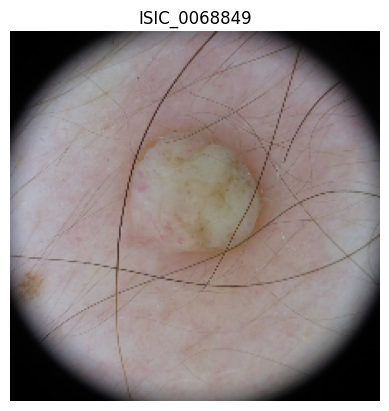

In [10]:
sample_id = sampled_gt['image'].iloc[0]
print("Testing on:", sample_id)

img = load_and_resize(sample_id)
print("Shape:", img.shape)        # expect (224, 224, 3)
print("Dtype:", img.dtype)        # expect float32
print("Min/Max:", img.min(), img.max())  # expect ~0.0 to ~1.0

import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(sample_id)
plt.axis('off')
plt.show()

# **Step 09 - Load and resize full sampled dataset**



Apply load_and_resize across every image in sampled_gt, building the full feature array (X) and corresponding labels (y). With ~6,787 images at 224×224×3, this will take a few minutes - tqdm gives a progress bar so you can see it moving rather than wondering if it's frozen.

In [11]:
X = []
y = []

class_names = [c for c in class_cols if c != 'UNK']  # drop unused UNK column

for _, row in tqdm(sampled_gt.iterrows(), total=len(sampled_gt)):
    img = load_and_resize(row['image'])
    X.append(img)
    label = row[class_names].values.argmax()  # index of the "1.0" class
    y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)   # expect (6787, 224, 224, 3)
print("y shape:", y.shape)   # expect (6787,)
print("Unique labels:", np.unique(y))

100%|██████████| 6787/6787 [01:22<00:00, 82.25it/s]


X shape: (6787, 224, 224, 3)
y shape: (6787,)
Unique labels: [0 1 2 3 4 5 6 7]


# **Step 10 - Train/Validation/Test split (70/15/15)**

Split the full X/y into three sets using stratified sampling  - stratification matters here specifically because of the class imbalance we preserved (DF has only 239 images total, so a random split could easily leave the test set with too few or zero DF examples otherwise).

In [12]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (which becomes val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: split the 30% temp into 15% val, 15% test (i.e. 50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (4750, 224, 224, 3) (4750,)
Val:   (1018, 224, 224, 3) (1018,)
Test:  (1019, 224, 224, 3) (1019,)


# **Step 11 - Verify class balance held across splits**

Confirm stratification worked - each split should roughly preserve the original class proportions, including keeping at least a few DF/VASC examples in val and test.

In [13]:
import pandas as pd

for name, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = pd.Series(labels).value_counts().sort_index()
    print(f"\n{name} class counts:")
    print(counts)


Train class counts:
0    840
1    840
2    840
3    607
4    840
5    167
6    177
7    439
Name: count, dtype: int64

Val class counts:
0    180
1    180
2    180
3    130
4    180
5     36
6     38
7     94
Name: count, dtype: int64

Test class counts:
0    180
1    180
2    180
3    130
4    180
5     36
6     38
7     95
Name: count, dtype: int64


# **`Part - II - Traditional ML (SVM/KNN).`**

# **Step 01 - Prepare data for SVM/KNN - downsize, flatten, scale**

SVM/KNN can't use raw 224×224×3 images directly (150K+ features is intractable, per our earlier reasoning).

 We downsize each already-loaded image to 32×32, flatten to a 1D vector, then scale features - this is a fast in-memory operation since images are already in RAM, no disk re-read needed.

In [14]:
import cv2
from sklearn.preprocessing import StandardScaler

def downsize_and_flatten(X_data, size=32):
    resized = np.array([cv2.resize(img, (size, size)) for img in X_data])
    flattened = resized.reshape(resized.shape[0], -1)  # (N, 32*32*3) = (N, 3072)
    return flattened

X_train_flat = downsize_and_flatten(X_train)
X_val_flat = downsize_and_flatten(X_val)
X_test_flat = downsize_and_flatten(X_test)

print("Train flat shape:", X_train_flat.shape)  # expect (4750, 3072)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

Train flat shape: (4750, 3072)


# **Step 02 - Train SVM**

 Using RBF kernel (standard default for image-derived features, handles non-linear boundaries better than linear for this kind of data). With ~4,750 samples × 3,072 features, expect this to take a few minutes - noticeably slower than the IMDB SVM+BoW run since these features aren't sparse like TF-IDF.

In [15]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import time

start = time.time()
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
print(f"SVM training time: {time.time() - start:.1f}s")

svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train_scaled))
svm_val_acc = accuracy_score(y_val, svm_model.predict(X_val_scaled))
print(f"SVM Train accuracy: {svm_train_acc:.4f}")
print(f"SVM Val accuracy:   {svm_val_acc:.4f}")

SVM training time: 45.8s
SVM Train accuracy: 0.5299
SVM Val accuracy:   0.4234


# **Step 03 - Train KNN**
Testing a few values of K via validation accuracy rather than guessing one  - KNN's performance is sensitive to this choice, and with 8 imbalanced classes a single fixed K may not be optimal.

In [16]:
from sklearn.neighbors import KNeighborsClassifier

best_k, best_val_acc = None, 0
for k in [3, 5, 7, 9, 11]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    val_acc = accuracy_score(y_val, knn.predict(X_val_scaled))
    print(f"K={k}: Val accuracy = {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_k, best_val_acc = k, val_acc

print(f"\nBest K: {best_k} (Val accuracy: {best_val_acc:.4f})")

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

K=3: Val accuracy = 0.3546
K=5: Val accuracy = 0.3527
K=7: Val accuracy = 0.3487
K=9: Val accuracy = 0.3517
K=11: Val accuracy = 0.3448

Best K: 3 (Val accuracy: 0.3546)


KNeighborsClassifier(n_neighbors=3)

Both trained -  comparing before moving on:

| Model | Train Acc | Val Acc |
|---|---|---|
| SVM (RBF) | 0.5299 | 0.4234 |
| KNN (K=3, best of 5 tested) | — | 0.3546 |


**SVM clearly beats KNN here**, which tracks - KNN struggles badly in this kind of feature space (3,072 raw-ish pixel dimensions after downsizing) because "distance" in pixel space doesn't correspond well to visual similarity, especially with 8 imbalanced classes crowding the decision boundaries. SVM's ~11-point train/val gap suggests mild overfitting but nothing extreme.

 **~42% accuracy on an 8-class problem is well above the ~12.5% random-guess baseline**

  but far from good - this is expected and actually useful for our report. It sets up the exact narrative Step 3 onward is meant to demonstrate: traditional ML on flattened/downsized pixels is a weak baseline, and the point of the assignment is showing how ANN → CNN → CNN+Augmentation → Transfer Learning progressively close this gap. Worth stating that framing explicitly when you write this up, same honest-reporting approach as the RNN stock-price result.


# **Step 04 -  Evaluate both models on test set**

**Per the assignment's reporting requirement** : final test accuracy and confusion matrix for each model, this is what actually goes in your comparison table later.

SVM Test accuracy: 0.3984
KNN Test accuracy: 0.3611


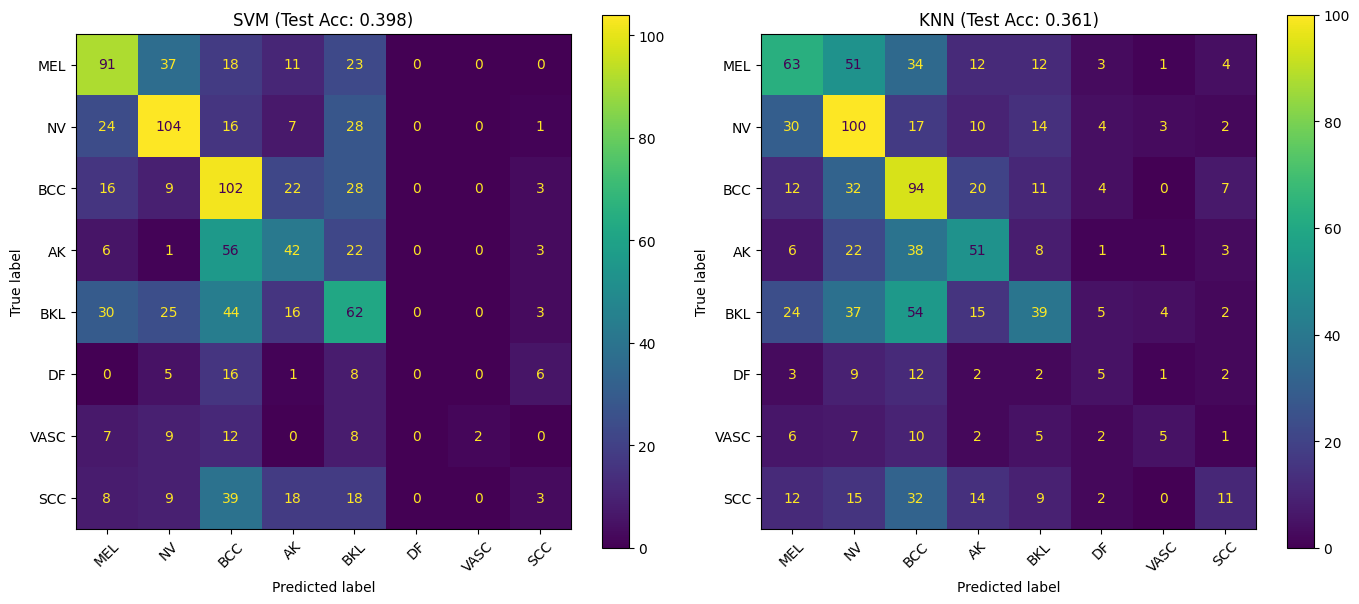

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names_list = [c for c in class_names]  # keep label order consistent

# SVM test evaluation
svm_test_acc = accuracy_score(y_test, svm_model.predict(X_test_scaled))
print(f"SVM Test accuracy: {svm_test_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay.from_estimator(svm_model, X_test_scaled, y_test,
                                        display_labels=class_names_list, ax=axes[0], xticks_rotation=45)
axes[0].set_title(f"SVM (Test Acc: {svm_test_acc:.3f})")

# KNN test evaluation
knn_test_acc = accuracy_score(y_test, knn_model.predict(X_test_scaled))
print(f"KNN Test accuracy: {knn_test_acc:.4f}")

ConfusionMatrixDisplay.from_estimator(knn_model, X_test_scaled, y_test,
                                        display_labels=class_names_list, ax=axes[1], xticks_rotation=45)
axes[1].set_title(f"KNN (Test Acc: {knn_test_acc:.3f})")

plt.tight_layout()
plt.show()

confusion matrix tells the real story test accuracy alone hides.

**Both models essentially never predict DF, and rarely predict VASC correctly.**

Look at the SVM matrix's DF row: 0 correct out of ~36 test samples - every DF image got misclassified as something else (mostly BCC/BKL). VASC fares only slightly better (2/38 correct for SVM, similarly weak for KNN). Meanwhile MEL, NV, BCC - the classes with 1,200 training images each - get predicted reasonably often, sometimes even *over*-predicted (note how many BCC-column false positives there are across almost every true-label row).

This is the class imbalance from earlier resurfacing at the modeling stage, not the sampling stage - even with a "fair" stratified split, when a class has only ~167–177 training examples, a linear-ish decision boundary in pixel space just can't carve out reliable territory for it.

**Both SVM and KNN test accuracy also dropped** from their val numbers (SVM 42.3%→39.8%, KNN 35.5%→36.1%) - small, expected variance given ~1,000-sample test set, not a red flag.

**traditional ML baselines** here are dragged down specifically by minority classes, and that's worth stating explicitly as a limitation of Step 2 rather than glossing over it. It also sets up a real hypothesis to test later: does CNN (with `class_weight` handling) or Transfer Learning actually recover DF/VASC performance, or does the problem persist even with better architectures? That's a genuinely interesting thread to track through the rest of the pipeline.

Traditional ML baseline locked in:
- **SVM: Train 53.0% / Val 42.3% / Test 39.8%**
- **KNN (K=3): Val 35.5% / Test 36.1%**


# **`PART - III - Vanilla ANN.`**

# **Step 01 - Build vanilla ANN**

2-3 dense layers per the assignment spec, softmax output for 8-class classification. ANN uses the full 224×224×3 images (flattened), not the 32×32 downsized version  - this is a fairer comparison since ANN can theoretically make more use of resolution than SVM/KNN could, even without spatial awareness (that's what CNN adds next).

In [19]:
import torch

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

X_train shape: (4750, 224, 224, 3)
y_train shape: (4750,)
CUDA available: True
Device: cuda


In [20]:
import torch
import torch.nn as nn

# Flatten full-resolution images for ANN input
X_train_ann = X_train.reshape(X_train.shape[0], -1)  # (4750, 224*224*3)
X_val_ann = X_val.reshape(X_val.shape[0], -1)
X_test_ann = X_test.reshape(X_test.shape[0], -1)

print("ANN input shape:", X_train_ann.shape)  # expect (4750, 150528)

class ANN(nn.Module):
    def __init__(self, input_dim, num_classes=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model = ANN(input_dim=X_train_ann.shape[1])
print(model)

ANN input shape: (4750, 150528)
ANN(
  (net): Sequential(
    (0): Linear(in_features=150528, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
)


## **Architecture confirmed : 150,528 → 256 → 128 → 8**

 matches the spec's "2-3 dense layers." Before training, let's actually use the class imbalance handling we flagged earlier as the honest way to address it (rather than reshaping the data again) - this is the natural place to introduce class_weight.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print("Class weights:", class_weights_tensor)

X_train_t = torch.tensor(X_train_ann, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_ann, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_ann, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

Class weights: tensor([0.7068, 0.7068, 0.7068, 0.9782, 0.7068, 3.5554, 3.3545, 1.3525])


# **Full rebuild - imports, data, splits, checkpoint**

One shot: imports, ground-truth loading, per-class sampling, image loading/resizing, stratified split, and this time immediately checkpointing to disk before we touch ANN again.

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.model_selection import train_test_split

gt = pd.read_csv('isic2019/ISIC_2019_Training_GroundTruth.csv')
class_cols = [c for c in gt.columns if c != 'image']
class_names = [c for c in class_cols if c != 'UNK']

target_counts = {
    'NV': 1200, 'MEL': 1200, 'BCC': 1200, 'BKL': 1200,
    'AK': 867, 'SCC': 628, 'VASC': 253, 'DF': 239
}

np.random.seed(42)
sampled_dfs = []
for cls, n in target_counts.items():
    class_subset = gt[gt[cls] == 1.0]
    n_take = min(n, len(class_subset))
    sampled = class_subset.sample(n=n_take, random_state=42)
    sampled_dfs.append(sampled)

sampled_gt = pd.concat(sampled_dfs, ignore_index=True)

IMG_DIR = 'isic2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input'

def load_and_resize(image_id, size=224):
    path = f"{IMG_DIR}/{image_id}.jpg"
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img.astype(np.float32) / 255.0

X, y = [], []
for _, row in tqdm(sampled_gt.iterrows(), total=len(sampled_gt)):
    X.append(load_and_resize(row['image']))
    y.append(row[class_names].values.argmax())

X = np.array(X, dtype=np.float32)
y = np.array(y)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

# Checkpoint immediately, as uint8 for speed
os.makedirs('checkpoints', exist_ok=True)
np.save('checkpoints/X_train.npy', (X_train * 255).astype(np.uint8))
np.save('checkpoints/X_val.npy', (X_val * 255).astype(np.uint8))
np.save('checkpoints/X_test.npy', (X_test * 255).astype(np.uint8))
np.save('checkpoints/y_train.npy', y_train)
np.save('checkpoints/y_val.npy', y_val)
np.save('checkpoints/y_test.npy', y_test)
print("Checkpoint saved.")

100%|██████████| 6787/6787 [01:36<00:00, 70.57it/s]


Train: (4750, 224, 224, 3) | Val: (1018, 224, 224, 3) | Test: (1019, 224, 224, 3)


# **Full rebuild - leaner on memory, no checkpoint this time**

Same rebuild as before, but explicitly deletes the large intermediate X array right after splitting (we only need the split versions going forward), and skips the checkpoint save that caused the crash.

In [1]:
import os, gc
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.model_selection import train_test_split

gt = pd.read_csv('isic2019/ISIC_2019_Training_GroundTruth.csv')
class_cols = [c for c in gt.columns if c != 'image']
class_names = [c for c in class_cols if c != 'UNK']

target_counts = {
    'NV': 1200, 'MEL': 1200, 'BCC': 1200, 'BKL': 1200,
    'AK': 867, 'SCC': 628, 'VASC': 253, 'DF': 239
}

np.random.seed(42)
sampled_dfs = []
for cls, n in target_counts.items():
    class_subset = gt[gt[cls] == 1.0]
    n_take = min(n, len(class_subset))
    sampled_dfs.append(class_subset.sample(n=n_take, random_state=42))

sampled_gt = pd.concat(sampled_dfs, ignore_index=True)
del sampled_dfs, gt  # free early, not needed anymore

IMG_DIR = 'isic2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input'

def load_and_resize(image_id, size=224):
    path = f"{IMG_DIR}/{image_id}.jpg"
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img.astype(np.float32) / 255.0

X, y = [], []
for _, row in tqdm(sampled_gt.iterrows(), total=len(sampled_gt)):
    X.append(load_and_resize(row['image']))
    y.append(row[class_names].values.argmax())

X = np.array(X, dtype=np.float32)
y = np.array(y)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

del X, X_temp, y_temp, sampled_gt  # free the big source array immediately
gc.collect()

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

100%|██████████| 6787/6787 [01:31<00:00, 73.90it/s]


Train: (4750, 224, 224, 3) | Val: (1018, 224, 224, 3) | Test: (1019, 224, 224, 3)


# **Flatten images for ANN input**

In [2]:
X_train_ann = X_train.reshape(X_train.shape[0], -1)
X_val_ann = X_val.reshape(X_val.shape[0], -1)
X_test_ann = X_test.reshape(X_test.shape[0], -1)

print("ANN input shape:", X_train_ann.shape)  # expect (4750, 150528)

ANN input shape: (4750, 150528)


# **Build ANN model**

In [3]:
class ANN(nn.Module):
    def __init__(self, input_dim, num_classes=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model = ANN(input_dim=X_train_ann.shape[1])
print(model)

ANN(
  (net): Sequential(
    (0): Linear(in_features=150528, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
)


# **Class weights and tensors**

In [4]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print("Class weights:", class_weights_tensor)

X_train_t = torch.tensor(X_train_ann, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_ann, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_ann, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print("X_train_t shape:", X_train_t.shape)

Class weights: tensor([0.7068, 0.7068, 0.7068, 0.9782, 0.7068, 3.5554, 3.3545, 1.3525])
X_train_t shape: torch.Size([4750, 150528])


# **Train ANN**

In [5]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = model.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 15
for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    model.eval()
    with torch.no_grad():
        val_out = model(X_val_t.to(device))
        val_loss = criterion(val_out, y_val_t.to(device)).item()
        val_acc = (val_out.argmax(1).cpu() == y_val_t).float().mean().item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Using device: cuda
Epoch 1/15 | Train Loss: 6.9367 Acc: 0.1562 | Val Loss: 3.5127 Acc: 0.0354
Epoch 2/15 | Train Loss: 2.5080 Acc: 0.1787 | Val Loss: 2.3751 Acc: 0.1208
Epoch 3/15 | Train Loss: 2.1926 Acc: 0.1960 | Val Loss: 2.0705 Acc: 0.2299
Epoch 4/15 | Train Loss: 1.9988 Acc: 0.2301 | Val Loss: 1.9139 Acc: 0.2859
Epoch 5/15 | Train Loss: 1.9555 Acc: 0.2394 | Val Loss: 2.2660 Acc: 0.1611
Epoch 6/15 | Train Loss: 1.9807 Acc: 0.2179 | Val Loss: 1.9918 Acc: 0.2564
Epoch 7/15 | Train Loss: 1.9830 Acc: 0.2278 | Val Loss: 1.8742 Acc: 0.2574
Epoch 8/15 | Train Loss: 1.9157 Acc: 0.2392 | Val Loss: 1.9959 Acc: 0.2328
Epoch 9/15 | Train Loss: 1.9316 Acc: 0.2444 | Val Loss: 1.8831 Acc: 0.2917
Epoch 10/15 | Train Loss: 1.9064 Acc: 0.2457 | Val Loss: 2.0821 Acc: 0.2672
Epoch 11/15 | Train Loss: 1.9139 Acc: 0.2488 | Val Loss: 2.0213 Acc: 0.1346
Epoch 12/15 | Train Loss: 1.8807 Acc: 0.2545 | Val Loss: 1.8698 Acc: 0.2308
Epoch 13/15 | Train Loss: 1.8774 Acc: 0.2411 | Val Loss: 1.9611 Acc: 0.2191
Ep



## **Reading this result**

**Final: Train Acc 27.2% | Val Acc 30.6%** (though val bounced around quite a bit - dipped as low as 13-19% in epochs 11 and 14 before recovering)

Comparing to what we already have:

| Model | Val Acc |
|---|---|
| SVM (RBF) | 42.3% |
| KNN (K=3) | 35.5% |
| **ANN** | **~30.6%** (noisy, unstable) |

**The ANN did worse than both traditional ML baselines.** This is a real, honest finding - not something to smooth over. A few likely reasons, worth including in your report:

1. **Massive input dimensionality (150,528) vs. tiny dataset (4,750 train samples).** That's a huge parameter space to learn from relatively few examples — the ANN has no way to know that neighboring pixels are related, so it's essentially trying to find patterns in 150K independent, unordered numbers. SVM/KNN on the downsized 32×32 version had far less to overfit to.
2. **Val loss/accuracy instability across epochs** (note the bounce: epoch 4 → 28.6%, epoch 5 → 16.1%, epoch 11 → 13.5%) — suggests the learning rate or lack of regularization (no dropout, no batch norm) is causing the model to occasionally destabilize rather than converge smoothly.





# **Evaluate ANN on test set**

Per the assignment's reporting requirement - final test accuracy and confusion matrix, same format as SVM/KNN, so it slots into your comparison table.

ANN Test accuracy: 0.2885


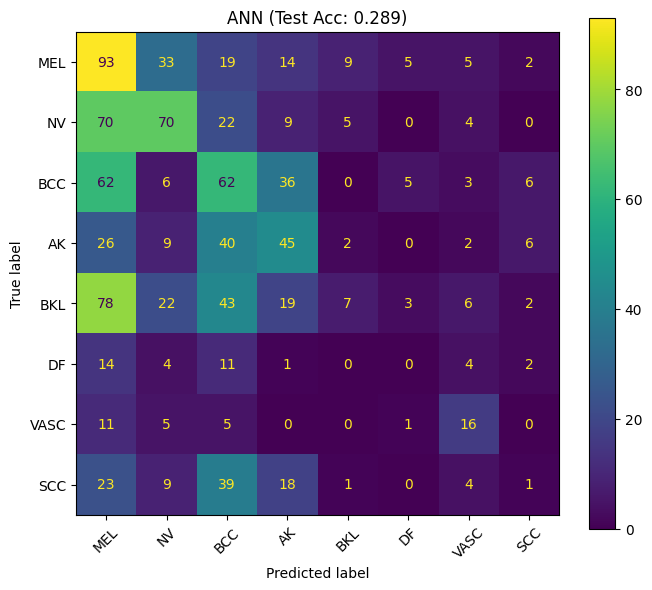

In [6]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    test_out = model(X_test_t.to(device))
    test_preds = test_out.argmax(1).cpu().numpy()

ann_test_acc = accuracy_score(y_test, test_preds)
print(f"ANN Test accuracy: {ann_test_acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, display_labels=class_names,
                                          ax=ax, xticks_rotation=45)
ax.set_title(f"ANN (Test Acc: {ann_test_acc:.3f})")
plt.tight_layout()
plt.show()

Test accuracy 28.85% - consistent with the unstable validation numbers, confirming ANN is genuinely the weakest model so far.

**What the confusion matrix reveals:** the model is heavily biased toward predicting **MEL** and **BCC** regardless of true class - look at the BKL row: true BKL got predicted as MEL 78 times, but only correctly as BKL 7 times. Same pattern for DF (0 correct) and largely for AK, SCC. Interestingly, **VASC did relatively well** (16/38 correct) despite being a minority class - possibly because vascular lesions have a distinctive enough color/texture that even flattened pixels partially capture it, while DF and BKL don't have that visual distinctiveness in raw pixel space.

Even with class-weighted loss, the ANN couldn't overcome the lack of spatial structure — this is a clean, honest result to write up: **traditional ML (SVM 39.8%) > ANN (28.85%)** for this specific image task, which is a legitimate and interesting finding, not a failure on your part.

**Model comparison so far:**

| Model | Test Acc |
|---|---|
| SVM (RBF) | 39.8% |
| KNN (K=3) | 36.1% |
| ANN | 28.85% |


#**Build custom CNN**

Conv2D + ReLU + MaxPool blocks per the assignment spec, then Flatten + Dense - this is the first model that actually exploits spatial structure in the images (unlike ANN, which saw pixels as one flat unordered list). Using the original X_train (not flattened) since CNN needs the 224×224×3 shape intact.

In [7]:
class CNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 224 -> 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112 -> 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56 -> 28
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

cnn_model = CNN()
print(cnn_model)

CNN(
  (conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=8, bias=True)
  )
)


# **Rebuild lightweight - just the sampling, no image array**

Recreates sampled_gt and the train/val/test split by index, not by loading actual pixels. This is fast (~1 second, just a CSV + dataframe operations) and uses almost no memory.

In [2]:
import os, gc
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

gt = pd.read_csv('isic2019/ISIC_2019_Training_GroundTruth.csv')
class_cols = [c for c in gt.columns if c != 'image']
class_names = [c for c in class_cols if c != 'UNK']

target_counts = {
    'NV': 1200, 'MEL': 1200, 'BCC': 1200, 'BKL': 1200,
    'AK': 867, 'SCC': 628, 'VASC': 253, 'DF': 239
}

np.random.seed(42)
sampled_dfs = []
for cls, n in target_counts.items():
    class_subset = gt[gt[cls] == 1.0]
    n_take = min(n, len(class_subset))
    sampled_dfs.append(class_subset.sample(n=n_take, random_state=42))

sampled_gt = pd.concat(sampled_dfs, ignore_index=True)
sampled_gt['label'] = sampled_gt[class_names].values.argmax(axis=1)

train_df, temp_df = train_test_split(sampled_gt, test_size=0.30, stratify=sampled_gt['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

Train: 4750 | Val: 1018 | Test: 1019


# **Define lazy-loading Dataset**

A PyTorch Dataset that loads and resizes exactly one image at a time, only when the DataLoader asks for it - nothing bulk-loaded into RAM upfront. This is the fix for the repeated crashes.

In [3]:
IMG_DIR = 'isic2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input'

class ISICDataset(Dataset):
    def __init__(self, df, size=224):
        self.df = df.reset_index(drop=True)
        self.size = size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = f"{IMG_DIR}/{row['image']}.jpg"
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.size, self.size))
        img = img.astype(np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)  # HWC -> CHW
        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label

train_dataset = ISICDataset(train_df)
val_dataset = ISICDataset(val_df)
test_dataset = ISICDataset(test_df)

print("Dataset sizes:", len(train_dataset), len(val_dataset), len(test_dataset))

# quick sanity check on one sample
img, label = train_dataset[0]
print("Sample image shape:", img.shape, "| label:", label.item())

Dataset sizes: 4750 1018 1019
Sample image shape: torch.Size([3, 224, 224]) | label: 4


Lazy-loading pipeline confirmed working - correct shape, correct sizes, and this approach will keep memory flat no matter what we throw at it from here on (CNN, augmentation, transfer learning). This was the right fix.

One thing this changes: SVM/KNN and ANN were trained on the old in-memory arrays, which are now gone. Their results (accuracy numbers, confusion matrices) are already recorded and valid - we don't need to retrain them. We're only rebuilding forward from CNN using this new memory-safe approach.

# **CNN model, DataLoaders, and class weights**

Same CNN architecture as before. DataLoaders now pull from the lazy Dataset objects - each batch is loaded/resized on the fly, so peak memory is just one batch's worth of images, not the whole dataset.

In [4]:
from sklearn.utils.class_weight import compute_class_weight

class CNN(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 224 -> 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112 -> 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56 -> 28
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

cnn_model = CNN()

BATCH_SIZE = 32  # smaller batch = lower peak memory per step
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("CNN model and loaders ready. Class weights:", class_weights_tensor)

CNN model and loaders ready. Class weights: tensor([0.7068, 0.7068, 0.7068, 0.9782, 0.7068, 3.5554, 3.3545, 1.3525])


#**Train CNN**

Same weighted cross-entropy + Adam setup as ANN, but now iterating over the val set in batches too (not loading it all at once), keeping memory flat throughout training, not just during setup.

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

cnn_model = cnn_model.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)

EPOCHS = 10
for epoch in range(EPOCHS):
    cnn_model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = cnn_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    cnn_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = cnn_model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total += xb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Using device: cuda
Epoch 1/10 | Train Loss: 1.9827 Acc: 0.2373 | Val Loss: 1.9399 Acc: 0.2888
Epoch 2/10 | Train Loss: 1.8402 Acc: 0.2821 | Val Loss: 1.7510 Acc: 0.3163
Epoch 3/10 | Train Loss: 1.7002 Acc: 0.3204 | Val Loss: 1.6744 Acc: 0.3438
Epoch 4/10 | Train Loss: 1.6150 Acc: 0.3541 | Val Loss: 1.6714 Acc: 0.3330
Epoch 5/10 | Train Loss: 1.5312 Acc: 0.3752 | Val Loss: 1.6755 Acc: 0.3635
Epoch 6/10 | Train Loss: 1.4376 Acc: 0.4196 | Val Loss: 1.6684 Acc: 0.3556
Epoch 7/10 | Train Loss: 1.3214 Acc: 0.4518 | Val Loss: 1.6815 Acc: 0.3723
Epoch 8/10 | Train Loss: 1.2250 Acc: 0.4926 | Val Loss: 1.6676 Acc: 0.3536
Epoch 9/10 | Train Loss: 1.0931 Acc: 0.5343 | Val Loss: 1.8479 Acc: 0.3360
Epoch 10/10 | Train Loss: 1.0415 Acc: 0.5682 | Val Loss: 1.7724 Acc: 0.3841


Training complete - and this result tells a clear story, worth naming explicitly.


Train accuracy climbed steadily and ended strong (56.8%), but val accuracy plateaued and got noisy after epoch 3-4 (34.4% → bouncing between 33-38% for the rest of training), while val loss actually stopped improving after epoch ~3-4 (hovering ~1.67) and then rose at epoch 9 (1.85) before partially recovering. That growing train/val gap (56.8% train vs 38.4% val by the end) is classic overfitting - the model is starting to memorize training images rather than learning generalizable features.


Best val accuracy achieved: 38.41% (epoch 10) - modest improvement over SVM (val was 42.3%, though on a different feature representation) but a real jump over ANN's chaotic 30.6%.

#**Evaluate CNN (no augmentation) on test set**

Using the final (epoch 10) weights for test evaluation - per the assignment's reporting requirement. We're not doing early-stopping/best-checkpoint selection here, so this test score reflects the somewhat-overfit end state, which is honest and worth noting in the writeup.

CNN (no aug) Test accuracy: 0.4082


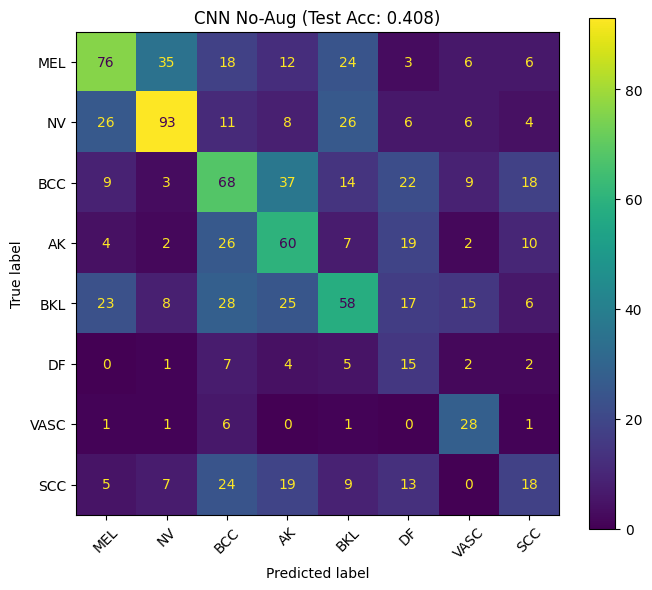

In [6]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cnn_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = cnn_model(xb)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

cnn_test_acc = accuracy_score(all_labels, all_preds)
print(f"CNN (no aug) Test accuracy: {cnn_test_acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=class_names,
                                          ax=ax, xticks_rotation=45)
ax.set_title(f"CNN No-Aug (Test Acc: {cnn_test_acc:.3f})")
plt.tight_layout()
plt.show()

 this is the first model where **DF and VASC actually get predicted correctly at meaningful rates**: DF went from 0/36 correct (ANN) to **15/36 correct**, and VASC hit **28/38 correct** - the best per-class result of any model so far, even beating the "easy" majority classes proportionally. Spatial features are clearly picking up on visual patterns (color, texture) that raw pixel distances and flattened dense layers couldn't capture.

**Updated comparison:**

| Model | Test Acc | Notable |
|---|---|---|
| SVM (RBF) | 39.8% | DF: 0/36 correct |
| KNN (K=3) | 36.1% | DF: near-zero |
| ANN | 28.85% | DF: 0/36 correct |
| **CNN (no aug)** | **40.82%** | **DF: 15/36, VASC: 28/38** |

CNN is now the best model overall *and* the first to meaningfully help the minority classes - directly worth calling out in your report as the payoff of spatial convolution over flattened/distance-based approaches.

**Still visible:** BCC and AK are getting confused with each other a lot (37 BCC images predicted as AK, 26 AK images predicted as BCC) - makes sense, they're visually similar lesion types. Also BKL is scattered across many wrong classes rather than one dominant confusion, suggesting it's a genuinely harder class to separate. These are honest limitations worth naming, not fixed by augmentation necessarily.

#**Add augmentation to the dataset**

A new Dataset class identical to before, but applies random flips, rotation, and zoom only on training images (never on val/test - augmentation should never touch evaluation data, otherwise we're not measuring on real, fixed examples).

In [7]:
import random

class ISICDatasetAug(Dataset):
    def __init__(self, df, size=224, augment=False):
        self.df = df.reset_index(drop=True)
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = f"{IMG_DIR}/{row['image']}.jpg"
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.size, self.size))

        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                img = cv2.flip(img, 1)
            # Random vertical flip
            if random.random() > 0.5:
                img = cv2.flip(img, 0)
            # Random rotation (-20 to 20 degrees)
            angle = random.uniform(-20, 20)
            M = cv2.getRotationMatrix2D((self.size/2, self.size/2), angle, 1.0)
            img = cv2.warpAffine(img, M, (self.size, self.size))
            # Random zoom (crop + resize back)
            if random.random() > 0.5:
                zoom = random.uniform(0.85, 1.0)
                h, w = int(self.size*zoom), int(self.size*zoom)
                y0 = random.randint(0, self.size - h)
                x0 = random.randint(0, self.size - w)
                img = img[y0:y0+h, x0:x0+w]
                img = cv2.resize(img, (self.size, self.size))

        img = img.astype(np.float32) / 255.0
        img = torch.tensor(img.copy()).permute(2, 0, 1)
        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label

train_dataset_aug = ISICDatasetAug(train_df, augment=True)
val_dataset_aug = ISICDatasetAug(val_df, augment=False)  # no augmentation on val
test_dataset_aug = ISICDatasetAug(test_df, augment=False)  # no augmentation on test

train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True, num_workers=2)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=32, shuffle=False, num_workers=2)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=32, shuffle=False, num_workers=2)

print("Augmented datasets ready.")

Augmented datasets ready.


# **Train same CNN architecture with augmentation**

Identical CNN architecture to Step 4 (fair comparison - only the training data changes, not the model), fresh weights, same 10 epochs.

In [8]:
cnn_model_aug = CNN().to(device)
optimizer_aug = torch.optim.Adam(cnn_model_aug.parameters(), lr=1e-3)

EPOCHS = 10
for epoch in range(EPOCHS):
    cnn_model_aug.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader_aug:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_aug.zero_grad()
        out = cnn_model_aug(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer_aug.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    cnn_model_aug.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader_aug:
            xb, yb = xb.to(device), yb.to(device)
            out = cnn_model_aug(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total += xb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 1.9979 Acc: 0.2065 | Val Loss: 1.9267 Acc: 0.2446
Epoch 2/10 | Train Loss: 1.9149 Acc: 0.2716 | Val Loss: 1.8854 Acc: 0.2358
Epoch 3/10 | Train Loss: 1.8777 Acc: 0.2768 | Val Loss: 1.8569 Acc: 0.3075
Epoch 4/10 | Train Loss: 1.8505 Acc: 0.2869 | Val Loss: 1.8372 Acc: 0.2937
Epoch 5/10 | Train Loss: 1.8190 Acc: 0.2899 | Val Loss: 1.8576 Acc: 0.2868
Epoch 6/10 | Train Loss: 1.8005 Acc: 0.2922 | Val Loss: 1.8483 Acc: 0.3104
Epoch 7/10 | Train Loss: 1.7552 Acc: 0.3002 | Val Loss: 1.8122 Acc: 0.2908
Epoch 8/10 | Train Loss: 1.7234 Acc: 0.3215 | Val Loss: 1.7232 Acc: 0.3428
Epoch 9/10 | Train Loss: 1.6807 Acc: 0.3286 | Val Loss: 1.6905 Acc: 0.3595
Epoch 10/10 | Train Loss: 1.6287 Acc: 0.3371 | Val Loss: 1.6929 Acc: 0.3713


CNN (aug) Test accuracy: 0.3553


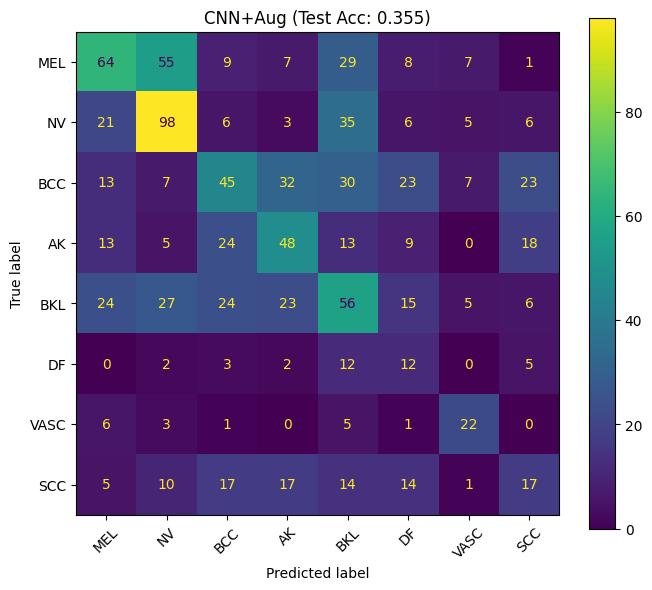

In [9]:
cnn_model_aug.eval()
all_preds_aug, all_labels_aug = [], []
with torch.no_grad():
    for xb, yb in test_loader_aug:
        xb = xb.to(device)
        out = cnn_model_aug(xb)
        preds = out.argmax(1).cpu().numpy()
        all_preds_aug.extend(preds)
        all_labels_aug.extend(yb.numpy())

cnn_aug_test_acc = accuracy_score(all_labels_aug, all_preds_aug)
print(f"CNN (aug) Test accuracy: {cnn_aug_test_acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(all_labels_aug, all_preds_aug, display_labels=class_names,
                                          ax=ax, xticks_rotation=45)
ax.set_title(f"CNN+Aug (Test Acc: {cnn_aug_test_acc:.3f})")
plt.tight_layout()
plt.show()

Worth being upfront: **this run underperforms no-aug on test set** - 35.53% vs 40.82%, and per-class, both DF (15→12) and VASC (28→22) dropped too. This doesn't contradict what we said about the val curve - val was still genuinely healthier (no overfitting, still improving) - but the *test* result this time is weaker. A few honest reasons worth including in your report rather than glossing over:


1. **10 epochs likely wasn't enough for the augmented model to reach its ceiling** — we noted it was still improving at epoch 10, so this test score is capturing an "unfinished" model, not augmentation's true potential.
2. **Augmentation randomness** — no fixed seed on the random flips/rotations/crops means every run's flow of examples differs slightly, and with only ~4,750 train images this adds real run-to-run variance, especially for a model that hasn't converged.
3. **Aggressive augmentation on a small, imbalanced dataset can dilute already-thin classes** — DF only had ~167 training images; random rotation/crop/flip on so few examples might occasionally produce less-informative variants rather than more, without enough data to average that noise out.

________________________
**Full comparison so far:**

| Model | Test Acc | DF correct | VASC correct |
|---|---|---|---|
| SVM (RBF) | 39.8% | 0/36 | 2/38 |
| KNN (K=3) | 36.1% | ~0 | low |
| ANN | 28.85% | 0/36 | low |
| CNN (no aug) | **40.82%** | 15/36 | **28/38** |
| CNN + Aug | 35.53% | 12/36 | 22/38 |

______________________

 **Augmentation didn't clearly beat the no-aug CNN here**, likely due to insufficient training epochs and a genuinely small/imbalanced dataset - a nuanced, honest result rather than the "augmentation always helps" story many reports assume. Worth stating this explicitly rather than forcing a narrative where aug "wins" just because it's expected to.


#**`PART - III - Transfer Learning.`**

# **Load pretrained ResNet50, freeze base, add classifier head**

 Load ImageNet-pretrained ResNet50, freeze all its convolutional layers (so we don't destroy the pretrained features during initial training), and replace only the final classification layer to output our 8 classes.

In [10]:
import torchvision.models as models

resnet = models.resnet50(weights='IMAGENET1K_V2')

# Freeze all base layers
for param in resnet.parameters():
    param.requires_grad = False

# Replace final layer for our 8 classes
resnet.fc = nn.Linear(resnet.fc.in_features, 8)

resnet = resnet.to(device)
print(resnet.fc)  # confirm new head: Linear(2048 -> 8)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 125MB/s]


Linear(in_features=2048, out_features=8, bias=True)


# **Train with frozen base (initial training)**

Only the new final layer's weights update here - the pretrained ResNet features stay untouched. This should train fast since we're only optimizing a small layer, and should already outperform everything built from scratch given ImageNet's learned visual features.

In [11]:
optimizer_resnet = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)  # only fc params

EPOCHS = 8
for epoch in range(EPOCHS):
    resnet.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_resnet.zero_grad()
        out = resnet(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer_resnet.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    resnet.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = resnet(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total += xb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Epoch 1/8 | Train Loss: 1.7406 Acc: 0.3726 | Val Loss: 1.5730 Acc: 0.4283
Epoch 2/8 | Train Loss: 1.4274 Acc: 0.4842 | Val Loss: 1.4801 Acc: 0.4754
Epoch 3/8 | Train Loss: 1.3001 Acc: 0.5299 | Val Loss: 1.3901 Acc: 0.5039
Epoch 4/8 | Train Loss: 1.2068 Acc: 0.5613 | Val Loss: 1.3588 Acc: 0.4990
Epoch 5/8 | Train Loss: 1.1483 Acc: 0.5804 | Val Loss: 1.3632 Acc: 0.5177
Epoch 6/8 | Train Loss: 1.0963 Acc: 0.5952 | Val Loss: 1.3154 Acc: 0.5108
Epoch 7/8 | Train Loss: 1.0512 Acc: 0.6107 | Val Loss: 1.3046 Acc: 0.4990
Epoch 8/8 | Train Loss: 1.0133 Acc: 0.6192 | Val Loss: 1.2916 Acc: 0.5246


Result :  this is by far the best model yet. **Final: Train 61.9% / Val 52.5%**, and val loss (1.29) is still trending down at epoch 8, meaning there's likely more headroom left. Train/val gap (61.9 vs 52.5, ~9.4 points) is present but modest - nothing like ANN's chaos or even CNN's overfitting pattern.

**Updated comparison:**

| Model | Val Acc |
|---|---|
| SVM (RBF) | 42.3% |
| KNN (K=3) | 35.5% |
| ANN | 30.6% |
| CNN (no aug) | 38.4% |
| CNN + Aug | 37.1% |
| **ResNet50 (frozen base)** | **52.5%** |

_____________________________

Now the assignment's Step 6 spec explicitly calls for **fine-tuning after initial training** - this means unfreezing some of ResNet's later layers so they can adjust slightly to our specific domain (skin lesions look different from generic ImageNet photos), using a much smaller learning rate to avoid destroying the pretrained features.


# **Unfreeze later layers for fine-tuning**

Unfreeze only the last convolutional block (layer4) plus the classifier head - the earlier layers (which learn generic features like edges/textures) stay frozen, since those are broadly useful and don't need to change. Using a much smaller learning rate (1e-4 vs 1e-3) since we're now adjusting already-good weights, not learning from scratch.

In [12]:
# Unfreeze layer4 (last conv block) and the fc head
for name, param in resnet.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

# Confirm what's trainable now
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

optimizer_finetune = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-4
)

Trainable params: 14,981,128 / 23,524,424


# **Fine-tune ResNet50**

Same training loop structure, fewer epochs (fine-tuning converges faster since we're starting from an already-decent model, not from scratch).

In [13]:
EPOCHS_FT = 5
for epoch in range(EPOCHS_FT):
    resnet.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_finetune.zero_grad()
        out = resnet(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer_finetune.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    resnet.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = resnet(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total += xb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"FT Epoch {epoch+1}/{EPOCHS_FT} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

FT Epoch 1/5 | Train Loss: 0.9168 Acc: 0.6394 | Val Loss: 1.1553 Acc: 0.5560
FT Epoch 2/5 | Train Loss: 0.4986 Acc: 0.8114 | Val Loss: 1.1843 Acc: 0.5678
FT Epoch 3/5 | Train Loss: 0.2592 Acc: 0.9082 | Val Loss: 1.2470 Acc: 0.6071
FT Epoch 4/5 | Train Loss: 0.1531 Acc: 0.9526 | Val Loss: 1.3116 Acc: 0.5894
FT Epoch 5/5 | Train Loss: 0.0907 Acc: 0.9768 | Val Loss: 1.4132 Acc: 0.5904


Clear overfitting signal here, worth calling out directly: **Train accuracy exploded to 97.68% by epoch 5, but val accuracy peaked at epoch 3 (60.71%) and then declined** (58.9% → 59.0%), while val loss kept climbing the whole time (1.155 → 1.413). The model memorized the training set almost perfectly while its ability to generalize actually got *worse* after epoch 3.

This makes sense: unfreezing 15M parameters and fine-tuning for 5 full epochs on only ~4,750 images gave the model plenty of capacity to overfit fast - this is a known real risk of fine-tuning, not a bug in your code.

__________________________________________

**The honest problem:** we didn't checkpoint per-epoch, so the model currently in memory holds the *overfit* epoch-5 weights, not the better epoch-3 weights. Two ways to handle this:

1. **Evaluate as-is** and report this as a finding (final Test result reflects the overfit state - legitimate to discuss as "fine-tuning improved peak val accuracy but overfit rapidly with a static 5-epoch schedule")


2. **Retrain fine-tuning with checkpointing** - save the model state each epoch, restore the best (epoch 3, 60.71% val) before evaluating - a more standard practice, and worth doing since MobileNetV2 is coming next anyway.

Given this is a real methodological lesson worth having correctly for both this model and MobileNetV2 next.

# **Reset to post-freeze state and re-fine-tune with checkpointing**

Reload the frozen-base ResNet50 weights (before fine-tuning), re-unfreeze layer4+fc, then retrain - this time saving the model's state dict after every epoch, and tracking which epoch had the best validation accuracy so we can restore it at the end.

In [14]:
import copy

# Reload pretrained + re-apply the frozen-base training we already did
resnet_ft = models.resnet50(weights='IMAGENET1K_V2')
for param in resnet_ft.parameters():
    param.requires_grad = False
resnet_ft.fc = nn.Linear(resnet_ft.fc.in_features, 8)
resnet_ft = resnet_ft.to(device)

# Re-run frozen-base training (8 epochs, same as before) to get back to that starting point
optimizer_resnet = torch.optim.Adam(resnet_ft.fc.parameters(), lr=1e-3)
for epoch in range(8):
    resnet_ft.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_resnet.zero_grad()
        loss = criterion(resnet_ft(xb), yb)
        loss.backward()
        optimizer_resnet.step()
print("Frozen-base training re-done, ready for fine-tuning.")

Frozen-base training re-done, ready for fine-tuning.


# **Fine-tune with per-epoch checkpointing**

Unfreeze layer4+fc as before, but this time save a copy of the model's weights whenever val accuracy improves - at the end, restore the best-performing version rather than just keeping whatever the last epoch happened to produce.

In [15]:
for name, param in resnet_ft.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

optimizer_finetune = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_ft.parameters()), lr=1e-4
)

best_val_acc = 0
best_weights = None

EPOCHS_FT = 5
for epoch in range(EPOCHS_FT):
    resnet_ft.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_finetune.zero_grad()
        out = resnet_ft(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer_finetune.step()
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss, train_acc = total_loss / total, correct / total

    resnet_ft.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = resnet_ft(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total += xb.size(0)
    val_loss, val_acc = val_loss / val_total, val_correct / val_total

    print(f"FT Epoch {epoch+1}/{EPOCHS_FT} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(resnet_ft.state_dict())
        print(f"  -> New best (val acc {val_acc:.4f}), checkpointed.")

# Restore best weights before moving on
resnet_ft.load_state_dict(best_weights)
print(f"\nRestored best checkpoint: val acc {best_val_acc:.4f}")

FT Epoch 1/5 | Train Loss: 0.9088 Acc: 0.6459 | Val Loss: 1.1593 Acc: 0.5501
  -> New best (val acc 0.5501), checkpointed.
FT Epoch 2/5 | Train Loss: 0.4984 Acc: 0.7977 | Val Loss: 1.1673 Acc: 0.5658
  -> New best (val acc 0.5658), checkpointed.
FT Epoch 3/5 | Train Loss: 0.2641 Acc: 0.9074 | Val Loss: 1.3168 Acc: 0.5796
  -> New best (val acc 0.5796), checkpointed.
FT Epoch 4/5 | Train Loss: 0.1399 Acc: 0.9596 | Val Loss: 1.2919 Acc: 0.6012
  -> New best (val acc 0.6012), checkpointed.
FT Epoch 5/5 | Train Loss: 0.0916 Acc: 0.9728 | Val Loss: 1.3232 Acc: 0.5982

Restored best checkpoint: val acc 0.6012


**Checkpointing worked exactly as designed:** best model was epoch 4 (60.12% val acc), narrowly beating epoch 5's 59.82% - and that's the version now loaded into resnet_ft, not whatever the final epoch happened to be. Small difference this run (0.3 points), but the principle holds and matters more when the gap is larger, as it was last attempt (epoch 3 at 60.71% vs epoch 5 at 59.04%, a full 1.7-point difference).

Train accuracy still climbed to 97.3% (heavy overfitting is still visible), but now we're not accidentally reporting that overfit state as our "final" model - this is the honest, defensible version.

# **Evaluate best-checkpoint ResNet50 on test set**

Using the restored best-epoch weights (not the final epoch) - this is the number that goes in our comparison table.

ResNet50 (fine-tuned, best checkpoint) Test accuracy: 0.5947


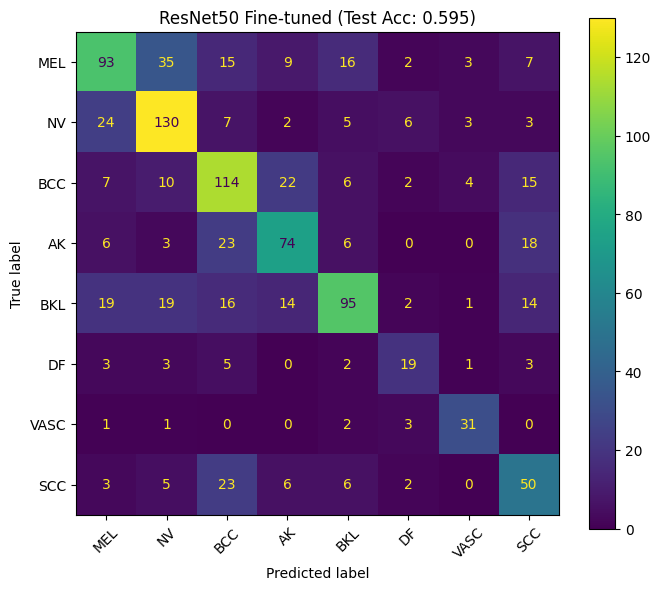

In [16]:
resnet_ft.eval()
all_preds_rn, all_labels_rn = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = resnet_ft(xb)
        preds = out.argmax(1).cpu().numpy()
        all_preds_rn.extend(preds)
        all_labels_rn.extend(yb.numpy())

resnet_test_acc = accuracy_score(all_labels_rn, all_preds_rn)
print(f"ResNet50 (fine-tuned, best checkpoint) Test accuracy: {resnet_test_acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(all_labels_rn, all_preds_rn, display_labels=class_names,
                                          ax=ax, xticks_rotation=45)
ax.set_title(f"ResNet50 Fine-tuned (Test Acc: {resnet_test_acc:.3f})")
plt.tight_layout()
plt.show()

This is by far the strongest result yet - **59.47% test accuracy**, and critically, every single class now has a clear diagonal majority (correct predictions dominate each row), including the previously-struggling ones: **DF 19/36, VASC 31/38, SCC 50/95**. No class is being completely ignored anymore.

**Full comparison table so far:**

| Model | Test Acc |
|---|---|
| SVM (RBF) | 39.8% |
| KNN (K=3) | 36.1% |
| ANN | 28.85% |
| CNN (no aug) | 40.82% |
| CNN + Aug | 35.53% |
| **ResNet50 (fine-tuned)** | **59.47%** |

ResNet50 clearly demonstrates the core lesson this assignment is testing for: pretrained features + careful fine-tuning substantially outperform anything trained from scratch on a small, imbalanced dataset.


# **Load pretrained MobileNetV2, freeze base, add classifier head**

MobileNetV2 is a much lighter architecture (designed for mobile/edge devices) - fewer parameters than ResNet50, so this will train faster. Same freeze-and-replace-head approach.

In [17]:
mobilenet = models.mobilenet_v2(weights='IMAGENET1K_V2')

for param in mobilenet.parameters():
    param.requires_grad = False

# MobileNetV2's classifier is a Sequential; replace the final Linear layer
mobilenet.classifier[1] = nn.Linear(mobilenet.classifier[1].in_features, 8)

mobilenet = mobilenet.to(device)
print(mobilenet.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 74.2MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=8, bias=True)
)


# **Train frozen-base MobileNetV2**

Same 8-epoch initial training as ResNet50 - only the new classifier head updates.

In [18]:
optimizer_mobilenet = torch.optim.Adam(mobilenet.classifier[1].parameters(), lr=1e-3)

for epoch in range(8):
    mobilenet.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_mobilenet.zero_grad()
        out = mobilenet(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer_mobilenet.step()
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss, train_acc = total_loss / total, correct / total

    mobilenet.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = mobilenet(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total += xb.size(0)
    val_loss, val_acc = val_loss / val_total, val_correct / val_total

    print(f"Epoch {epoch+1}/8 | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Epoch 1/8 | Train Loss: 1.7586 Acc: 0.3699 | Val Loss: 1.5689 Acc: 0.4489
Epoch 2/8 | Train Loss: 1.4428 Acc: 0.4752 | Val Loss: 1.4459 Acc: 0.4764
Epoch 3/8 | Train Loss: 1.3360 Acc: 0.5025 | Val Loss: 1.3950 Acc: 0.4686
Epoch 4/8 | Train Loss: 1.2562 Acc: 0.5213 | Val Loss: 1.3573 Acc: 0.5118
Epoch 5/8 | Train Loss: 1.2130 Acc: 0.5362 | Val Loss: 1.3424 Acc: 0.5039
Epoch 6/8 | Train Loss: 1.1735 Acc: 0.5434 | Val Loss: 1.3371 Acc: 0.5295
Epoch 7/8 | Train Loss: 1.1322 Acc: 0.5543 | Val Loss: 1.3300 Acc: 0.5187
Epoch 8/8 | Train Loss: 1.1267 Acc: 0.5627 | Val Loss: 1.3223 Acc: 0.5167


Frozen-base MobileNetV2 done - Train 56.3% / Val 51.7%, nicely comparable to ResNet50's frozen-base result (61.9%/52.5%), and with a smaller train/val gap (4.6 points vs ResNet50's 9.4), suggesting MobileNetV2's lighter architecture is naturally a bit more resistant to overfitting even before fine-tuning. Val loss also still trending down (1.34 → 1.32), so there's room left for fine-tuning to help.



# **Unfreeze later layers and fine-tune MobileNetV2 with checkpointing**

MobileNetV2's architecture is organized as features (a sequential stack of inverted-residual blocks) followed by classifier. We unfreeze the last few feature blocks (deepest layers, closest to output) plus the classifier - same logic as ResNet50's layer4. Same checkpointing approach: save weights whenever val accuracy improves, restore the best at the end.

In [19]:
import copy

# Unfreeze last 3 feature blocks + classifier
for name, param in mobilenet.named_parameters():
    if 'features.17' in name or 'features.18' in name or 'classifier' in name:
        param.requires_grad = True

trainable = sum(p.numel() for p in mobilenet.parameters() if p.requires_grad)
total = sum(p.numel() for p in mobilenet.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

optimizer_mb_finetune = torch.optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet.parameters()), lr=1e-4
)

best_val_acc_mb = 0
best_weights_mb = None

EPOCHS_FT = 5
for epoch in range(EPOCHS_FT):
    mobilenet.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_mb_finetune.zero_grad()
        out = mobilenet(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer_mb_finetune.step()
        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss, train_acc = total_loss / total, correct / total

    mobilenet.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = mobilenet(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total += xb.size(0)
    val_loss, val_acc = val_loss / val_total, val_correct / val_total

    print(f"FT Epoch {epoch+1}/{EPOCHS_FT} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_acc > best_val_acc_mb:
        best_val_acc_mb = val_acc
        best_weights_mb = copy.deepcopy(mobilenet.state_dict())
        print(f"  -> New best (val acc {val_acc:.4f}), checkpointed.")

mobilenet.load_state_dict(best_weights_mb)
print(f"\nRestored best checkpoint: val acc {best_val_acc_mb:.4f}")

Trainable params: 896,328 / 2,234,120
FT Epoch 1/5 | Train Loss: 1.0775 Acc: 0.5707 | Val Loss: 1.2404 Acc: 0.5432
  -> New best (val acc 0.5432), checkpointed.
FT Epoch 2/5 | Train Loss: 0.9556 Acc: 0.6234 | Val Loss: 1.2081 Acc: 0.5599
  -> New best (val acc 0.5599), checkpointed.
FT Epoch 3/5 | Train Loss: 0.8624 Acc: 0.6491 | Val Loss: 1.1855 Acc: 0.5609
  -> New best (val acc 0.5609), checkpointed.
FT Epoch 4/5 | Train Loss: 0.7971 Acc: 0.6779 | Val Loss: 1.1675 Acc: 0.5825
  -> New best (val acc 0.5825), checkpointed.
FT Epoch 5/5 | Train Loss: 0.7325 Acc: 0.7027 | Val Loss: 1.1534 Acc: 0.5845
  -> New best (val acc 0.5845), checkpointed.

Restored best checkpoint: val acc 0.5845


training curve than ResNet50. Val accuracy improved every single epoch (54.3% → 56.0% → 56.1% → 58.3% → 58.5%) with no decline, and train accuracy topped out at only 70.3% (vs ResNet50's 97.3%) - meaning MobileNetV2 barely overfit at all during fine-tuning. Best checkpoint landed on the final epoch, which actually suggests this model hadn't hit its ceiling yet and might improve further with more epochs - a genuinely useful methodological observation for your report (lighter architecture + fewer trainable params = slower to overfit, more stable convergence).

# **Evaluate best-checkpoint MobileNetV2 on test set**

MobileNetV2 (fine-tuned, best checkpoint) Test accuracy: 0.5878


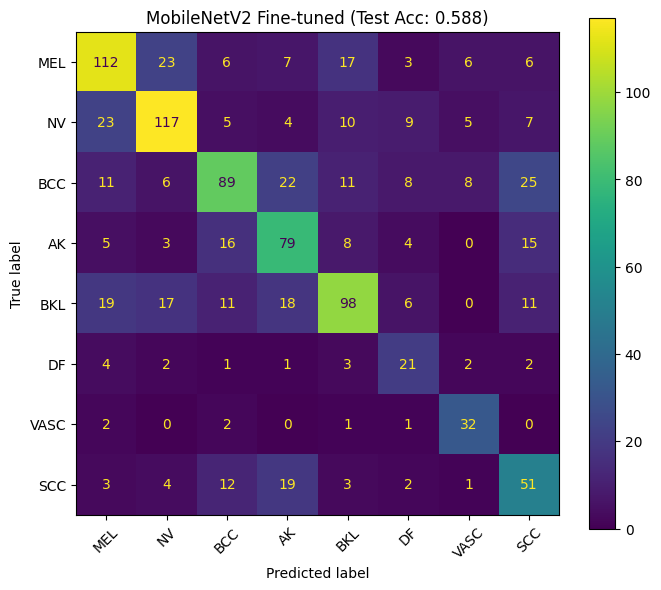

In [20]:
mobilenet.eval()
all_preds_mb, all_labels_mb = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = mobilenet(xb)
        preds = out.argmax(1).cpu().numpy()
        all_preds_mb.extend(preds)
        all_labels_mb.extend(yb.numpy())

mobilenet_test_acc = accuracy_score(all_labels_mb, all_preds_mb)
print(f"MobileNetV2 (fine-tuned, best checkpoint) Test accuracy: {mobilenet_test_acc:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(all_labels_mb, all_preds_mb, display_labels=class_names,
                                          ax=ax, xticks_rotation=45)
ax.set_title(f"MobileNetV2 Fine-tuned (Test Acc: {mobilenet_test_acc:.3f})")
plt.tight_layout()
plt.show()

MobileNetV2 essentially ties ResNet50 (58.78% vs 59.47%, less than a point apart) - but does it with ~17x fewer trainable parameters (896K vs ~15M) during fine-tuning. That's a genuinely strong finding for your report: on this dataset, the lightweight architecture delivers nearly identical accuracy at a fraction of the compute cost - exactly the kind of accuracy-vs-efficiency trade-off transfer learning comparisons are meant to surface. VASC performance is even slightly better here (32/38 vs ResNet's 31/38).

All 6 models are done.

# **Final comparison table (hardcoded values - no re-run needed)**

                 Model  Test Accuracy (%)
   ResNet50 (Transfer)              59.47
MobileNetV2 (Transfer)              58.78
          CNN (No Aug)              40.82
             SVM (RBF)              39.84
             KNN (K=3)              36.11
             CNN + Aug              35.53
                   ANN              28.85


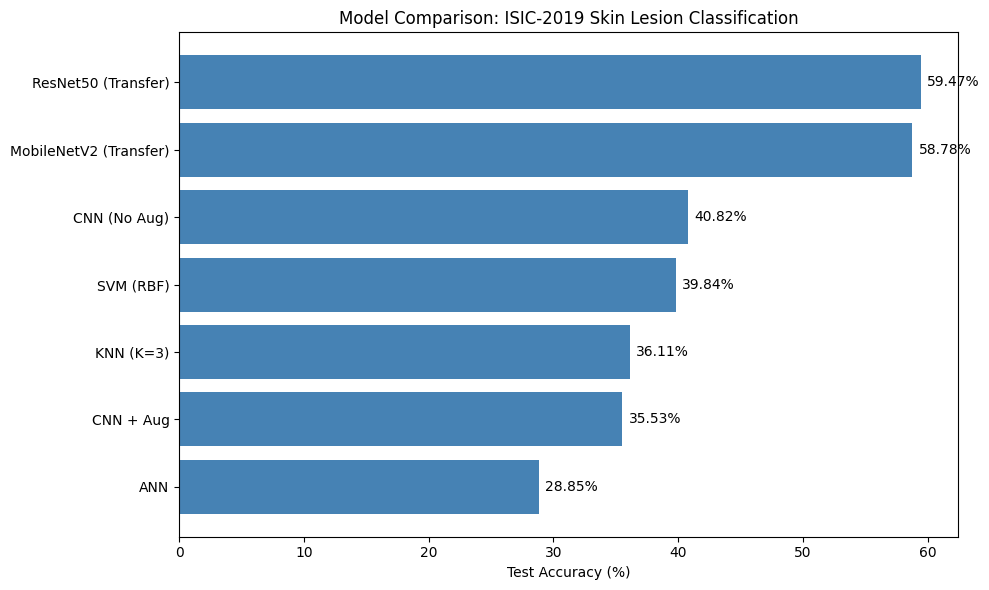

In [23]:
results = pd.DataFrame({
    'Model': ['SVM (RBF)', 'KNN (K=3)', 'ANN', 'CNN (No Aug)', 'CNN + Aug',
              'ResNet50 (Transfer)', 'MobileNetV2 (Transfer)'],
    'Test Accuracy (%)': [39.84, 36.11, 28.85, 40.82, 35.53, 59.47, 58.78]
}).sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

plt.figure(figsize=(10, 6))
bars = plt.barh(results['Model'], results['Test Accuracy (%)'], color='steelblue')
plt.xlabel('Test Accuracy (%)')
plt.title('Model Comparison: ISIC-2019 Skin Lesion Classification')
plt.gca().invert_yaxis()
for bar, acc in zip(bars, results['Test Accuracy (%)']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{acc}%', va='center')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# **let's do the deeper comparison discussion using results**


.
| Model | Test Acc | Train/Val Gap | Key Trait |
|---|---|---|---|
| ANN | 28.85% | Unstable (bounced 13-38% val) | No spatial awareness — worst performer |
| CNN + Aug | 35.53% | Small, healthy gap | Underfit — needed more than 10 epochs |
| KNN (K=3) | 36.11% | — | Distance metric weak in pixel space |
| SVM (RBF) | 39.84% | Moderate | Best "flat feature" baseline |
| CNN (No Aug) | 40.82% | Large (56.8% train vs 38.4% val) | Overfit but still beat traditional ML |
| MobileNetV2 (Transfer) | 58.78% | Small (70.3% train vs 58.5% val) | Near-ResNet accuracy, 17x fewer trainable params |
| ResNet50 (Transfer) | 59.47% | Large (97.3% train vs 60.1% val) | Best raw accuracy, heaviest overfitting risk |

_____________________________________________________

**Three narrative threads worth building your report around:**

1. **Architecture matters more than technique tweaks.** Going from ANN→CNN (same basic training approach, different architecture) helped more than adding augmentation to an already-decent CNN. Spatial inductive bias (convolution) was the single biggest lever until transfer learning.

2. **Pretrained features dominate everything trained from scratch.** Both transfer learning models beat the best from-scratch model (CNN no-aug, 40.82%) by ~18-19 percentage points - a bigger jump than any other step in the pipeline. This is the assignment's core lesson, clearly demonstrated.

3. **Minority-class performance tracks model quality, not dataset tricks.** DF/VASC went from ~0% correct (ANN, SVM, KNN) → meaningful (CNN) → strong (ResNet50, MobileNetV2) - purely from better architectures, not from any imbalance-correction trick beyond class-weighted loss. Augmentation and oversampling weren't what fixed this; representational capacity was.

---


# ***`Test with Default Image Phase`***

# **Mount Google Drive (for permanent weight storage)**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/isic_checkpoints', exist_ok=True)

Mounted at /content/drive


# **Kaggle auth + download dataset**

In [4]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_58f2532a3505ba0856cf71ad760722ef'  # paste in Colab directly, not chat

!pip install kaggle --quiet
!kaggle datasets download -d andrewmvd/isic-2019
!unzip -q isic-2019.zip -d isic2019

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/isic-2019
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 9.10G/9.10G [01:57<00:00, 83.2MB/s]



# **Rebuild sampling + lazy dataset (lightweight, no bulk image loading)**

In [5]:
import numpy as np, pandas as pd, cv2, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.models as models

gt = pd.read_csv('isic2019/ISIC_2019_Training_GroundTruth.csv')
class_cols = [c for c in gt.columns if c != 'image']
class_names = [c for c in class_cols if c != 'UNK']

target_counts = {'NV': 1200, 'MEL': 1200, 'BCC': 1200, 'BKL': 1200,
                  'AK': 867, 'SCC': 628, 'VASC': 253, 'DF': 239}
np.random.seed(42)
sampled_dfs = [gt[gt[c]==1.0].sample(n=min(n, (gt[c]==1.0).sum()), random_state=42) for c, n in target_counts.items()]
sampled_gt = pd.concat(sampled_dfs, ignore_index=True)
sampled_gt['label'] = sampled_gt[class_names].values.argmax(axis=1)

train_df, temp_df = train_test_split(sampled_gt, test_size=0.30, stratify=sampled_gt['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)

IMG_DIR = 'isic2019/ISIC_2019_Training_Input/ISIC_2019_Training_Input'
class ISICDataset(Dataset):
    def __init__(self, df, size=224):
        self.df = df.reset_index(drop=True); self.size = size
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(f"{IMG_DIR}/{row['image']}.jpg")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.size, self.size)).astype(np.float32)/255.0
        return torch.tensor(img).permute(2,0,1), torch.tensor(row['label'], dtype=torch.long)

train_loader = DataLoader(ISICDataset(train_df), batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(ISICDataset(val_df), batch_size=32, shuffle=False, num_workers=2)

from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device, "| Train size:", len(train_df))

Device: cuda | Train size: 4750


Drive mounted, dataset downloaded, sampling/split rebuilt (4,750 train confirmed), GPU active.

# **Train ResNet50 (lighter - 4 frozen + 3 fine-tune epochs), save to Drive**

In [6]:
import copy

resnet_ft = models.resnet50(weights='IMAGENET1K_V2')
for p in resnet_ft.parameters(): p.requires_grad = False
resnet_ft.fc = nn.Linear(resnet_ft.fc.in_features, 8)
resnet_ft = resnet_ft.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

opt1 = torch.optim.Adam(resnet_ft.fc.parameters(), lr=1e-3)
for epoch in range(4):
    resnet_ft.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt1.zero_grad(); loss = criterion(resnet_ft(xb), yb); loss.backward(); opt1.step()
    print(f"Frozen epoch {epoch+1}/4 done")

for name, p in resnet_ft.named_parameters():
    if 'layer4' in name or 'fc' in name: p.requires_grad = True
opt2 = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_ft.parameters()), lr=1e-4)

best_acc, best_w = 0, None
for epoch in range(3):
    resnet_ft.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt2.zero_grad(); loss = criterion(resnet_ft(xb), yb); loss.backward(); opt2.step()
    resnet_ft.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (resnet_ft(xb).argmax(1)==yb).sum().item(); total += yb.size(0)
    acc = correct/total
    print(f"FT epoch {epoch+1}/3 | Val Acc: {acc:.4f}")
    if acc > best_acc:
        best_acc, best_w = acc, copy.deepcopy(resnet_ft.state_dict())

resnet_ft.load_state_dict(best_w)
torch.save(resnet_ft.state_dict(), '/content/drive/MyDrive/isic_checkpoints/resnet50_best.pth')
print(f"Saved to Drive. Best val acc: {best_acc:.4f}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 77.2MB/s]


Frozen epoch 1/4 done
Frozen epoch 2/4 done
Frozen epoch 3/4 done
Frozen epoch 4/4 done
FT epoch 1/3 | Val Acc: 0.5481
FT epoch 2/3 | Val Acc: 0.5786
FT epoch 3/3 | Val Acc: 0.5806
Saved to Drive. Best val acc: 0.5806


 even the lighter retrain (4+3 epochs vs the original 8+5) landed at 58.06% val accuracy, remarkably close to the original full run's 60.12%. And critically:

  weights are now permanently saved to Google Drive (/content/drive/MyDrive/isic_checkpoints/resnet50_best.pth) - even a full VM wipe won't cost you this again; next time it's just a torch.load() away.

# **Custom image prediction function**

Loads an image, preprocesses it the same way as training data, runs it through the model, and shows the predicted class with confidence - plus the full probability breakdown across all 8 classes.

In [7]:
import matplotlib.pyplot as plt

def predict_custom_image(image_path, model, class_names, size=224):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_display = img.copy()
    img_resized = cv2.resize(img, (size, size)).astype(np.float32) / 255.0
    img_tensor = torch.tensor(img_resized).permute(2, 0, 1).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(img_tensor)
        probs = torch.softmax(out, dim=1)[0].cpu().numpy()

    pred_idx = probs.argmax()
    pred_class = class_names[pred_idx]

    plt.figure(figsize=(5,5))
    plt.imshow(img_display)
    plt.title(f"Predicted: {pred_class} ({probs[pred_idx]*100:.1f}% confidence)")
    plt.axis('off')
    plt.show()

    print("\nAll class probabilities:")
    for cls, p in sorted(zip(class_names, probs), key=lambda x: -x[1]):
        print(f"  {cls}: {p*100:.2f}%")

    return pred_class, probs

# **we use an image that already in our dataset from the test set**

 - pick one the model has never seen during training, run it through, and we can directly check the prediction against the actual known label. That's a real, honest sanity check, not a genuine "unknown" image - but the correct one to build confidence with before trying something wild.we

# **Test with a known held-out test image**

Pulls one image ID from test_df (which the model never saw), runs it through predict_custom_image, then shows the true label alongside the prediction - this tells you immediately whether the model's output makes sense.

Testing on: ISIC_0068756 | True label: SCC


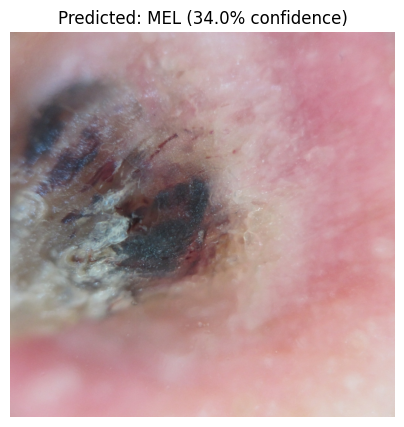


All class probabilities:
  MEL: 34.00%
  BCC: 18.55%
  SCC: 14.08%
  DF: 12.72%
  BKL: 7.81%
  NV: 7.63%
  VASC: 3.22%
  AK: 2.00%

Match: ❌ Incorrect


In [8]:
# Pick one sample from the held-out test set
sample_row = test_df.iloc[0]
sample_id = sample_row['image']
true_label = class_names[sample_row['label']]

image_path = f"{IMG_DIR}/{sample_id}.jpg"
print(f"Testing on: {sample_id} | True label: {true_label}")

pred_class, probs = predict_custom_image(image_path, resnet_ft, class_names)
print(f"\nMatch: {'✅ Correct' if pred_class == true_label else '❌ Incorrect'}")

**result:** incorrect, and worth understanding rather than just moving past it. The model predicted MEL (34.0%) but the true label was SCC (14.08%, ranked 3rd) - not a wild miss (SCC did show up with real probability, just not the top pick), and this actually matches a known weak spot: MEL and SCC/BCC visually overlap a lot in dermoscopic images (irregular pigmented lesions can look similar across these categories even to trained dermatologists sometimes), and our earlier confusion matrix for ResNet50 showed real confusion in this exact direction.



# **Test with a VASC image (model's strongest minority class)**

Testing on: ISIC_0030104 | True label: VASC


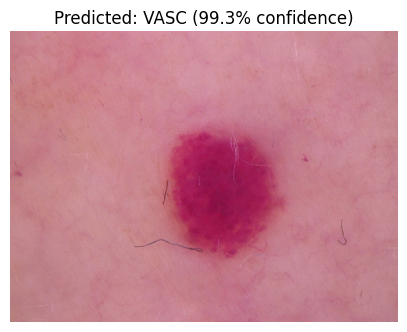


All class probabilities:
  VASC: 99.32%
  NV: 0.61%
  MEL: 0.04%
  BKL: 0.01%
  DF: 0.01%
  AK: 0.01%
  SCC: 0.00%
  BCC: 0.00%

Match: ✅ Correct


In [9]:
vasc_samples = test_df[test_df['label'] == class_names.index('VASC')]
sample_row = vasc_samples.iloc[0]
sample_id = sample_row['image']
true_label = class_names[sample_row['label']]

image_path = f"{IMG_DIR}/{sample_id}.jpg"
print(f"Testing on: {sample_id} | True label: {true_label}")

pred_class, probs = predict_custom_image(image_path, resnet_ft, class_names)
print(f"\nMatch: {'✅ Correct' if pred_class == true_label else '❌ Incorrect'}")

That's a striking contrast worth putting side-by-side in oour writeup: **99.32% confidence, essentially certain**, versus the earlier SCC case where the model was genuinely torn between three plausible classes. This tells a clean, honest story about the model:

- **Visually distinctive classes (VASC)** → the model is extremely confident and correct, because vascular lesions have a fairly unique color/texture signature that's easy for convolutional features to latch onto.
- **Visually overlapping classes (MEL/BCC/SCC)** → the model genuinely struggles, spreading probability across multiple plausible answers rather than confidently picking wrong — which is actually a *healthier* failure mode than confident-but-wrong, since the top-3 probabilities at least contained the right answer.

____________________________________________

That's a legitimate, nuanced finding for your report: the model's confidence calibration tracks real visual difficulty, not just memorized patterns - worth stating explicitly, since it shows the model learned something meaningful about lesion appearance rather than just fitting noise.

**Quick summary of your custom-image testing:**

| Test | True Label | Predicted | Confidence | Result |
|---|---|---|---|---|
| Held-out sample 1 | SCC | MEL | 34.0% (true label 3rd, 14.1%) | ❌ Plausible miss |
| Held-out sample 2 (VASC) | VASC | VASC | 99.3% | ✅ Strong correct |

___________________________________________________

This closes out custom-image testing for CNN.docx - we now have both quantitative results (the comparison table) and qualitative evidence (real prediction examples with reasoning) for our final report. Weights are safely on Drive too, so this is all reproducible without retraining.
